In [1]:
library(readxl)
library(dplyr)
library(tidyr)
library(stringr)
library(psych)      # PCA / fator
library(scales)
library(lavaan)
library(semTools)

Warning message:
"pacote 'readxl' foi compilado no R versão 4.5.3"

Anexando pacote: 'dplyr'


Os seguintes objetos são mascarados por 'package:stats':

    filter, lag


Os seguintes objetos são mascarados por 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"pacote 'psych' foi compilado no R versão 4.5.3"

Anexando pacote: 'scales'


Os seguintes objetos são mascarados por 'package:psych':

    alpha, rescale




In [159]:
library(lavaan)

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.


Anexando pacote: 'lavaan'


O seguinte objeto é mascarado por 'package:psych':

    cor2cov




In [167]:
library(semTools)

 

###############################################################################

This is semTools 0.5-7

All users of R (or SEM) are invited to submit functions or ideas for functions.

###############################################################################


Anexando pacote: 'semTools'


Os seguintes objetos são mascarados por 'package:psych':

    reliability, skew




In [115]:
tech <- read_excel("Technology_Skills.xlsx")
skills <- read_excel("Skills.xlsx")
activities <- read_excel("Work_Activities.xlsx")

### Definir elementos

In [116]:
tech_skills <- c(
  "Programming",
  "Systems Analysis",
  "Systems Evaluation",
  "Technology Design",
  "Operations Analysis"
)

tech_activities <- c(
  "Working with Computers",
  "Processing Information",
  "Analyzing Data or Information",
  "Updating and Using Relevant Knowledge"
)

In [117]:
skills_f <- skills %>%
  filter(
    `Element Name` %in% tech_skills,
    `Scale ID` == "IM"
  )

activities_f <- activities %>%
  filter(
    `Element Name` %in% tech_activities,
    `Scale ID` == "IM"
  )

In [118]:
skills_agg <- skills_f %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    tech_skill_score = mean(`Data Value`, na.rm = TRUE)
  )

activities_agg <- activities_f %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    tech_activity_score = mean(`Data Value`, na.rm = TRUE)
  )

In [119]:
tech_agg <- tech %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_tech = n_distinct(Example),
    n_hot = sum(`Hot Technology` == "Y", na.rm = TRUE),
    n_demand = sum(`In Demand` == "Y", na.rm = TRUE)
  )

In [120]:
df <- tech_agg %>%
  left_join(skills_agg, by = "O*NET-SOC Code") %>%
  left_join(activities_agg, by = "O*NET-SOC Code")

In [121]:
df_clean <- df %>%
  filter(
    !is.na(tech_skill_score),
    !is.na(tech_activity_score)
  )

In [122]:
df_clean <- df_clean %>%
  mutate(
    n_tech_log = log1p(n_tech),
    n_hot_log = log1p(n_hot),
    n_demand_log = log1p(n_demand)
  )

In [128]:
features <- df_clean %>%
  select(n_tech_log, n_hot_log, n_demand_log,
         tech_skill_score, tech_activity_score)

features_scaled <- scale(features)

In [133]:
dim(features)
colSums(is.na(features))
apply(features, 2, var)

[1] 894   5

n_tech_log           n_hot_log        n_demand_log    tech_skill_score 
                  0                   0                   0                   0 
tech_activity_score 
                  0

n_tech_log           n_hot_log        n_demand_log    tech_skill_score 
          0.8233536           0.6585305           0.8295420           0.2046601 
tech_activity_score 
          0.3972560

In [130]:
pca <- principal(features_scaled, nfactors = 1, rotate = "none")
df_clean$theta <- as.vector(features_scaled %*% pca$loadings)

In [135]:
# infraestrutura
infra <- df_clean %>%
  select(n_tech_log, n_hot_log, n_demand_log)

# uso
use <- df_clean %>%
  select(tech_skill_score, tech_activity_score)

In [136]:
pca_infra <- principal(scale(infra), nfactors = 1)
pca_use <- principal(scale(use), nfactors = 1)

df_clean$theta_infra <- as.vector(scale(infra) %*% pca_infra$loadings)
df_clean$theta_use   <- as.vector(scale(use) %*% pca_use$loadings)

In [140]:
df_tech <- df_clean
head(df_tech, 10)

O*NET-SOC Code,n_tech,n_hot,n_demand,tech_skill_score,tech_activity_score,n_tech_log,n_hot_log,n_demand_log,theta,theta_infra,theta_use
<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
11-1011.00,49,16,4,2.998,4.3300,3.912023,2.833213,1.609438,4.673605,2.270051,2.7982441
11-1011.03,21,14,4,2.880,4.1575,3.091042,2.708050,1.609438,3.276644,1.281324,2.3054400
11-1021.00,146,49,3,2.348,4.0950,4.990433,3.912023,1.386294,5.235328,4.411903,1.1298305
11-2011.00,73,27,6,2.498,3.7900,4.304065,3.332205,1.945910,4.305438,3.570686,0.9893797
11-2021.00,153,67,6,2.752,3.8350,5.036953,4.219508,1.945910,6.537455,5.349085,1.5728421
11-2022.00,103,39,5,2.596,4.0100,4.644391,3.688879,1.791759,5.359731,4.185421,1.5109061
11-2033.00,61,24,8,2.350,3.9400,4.127134,3.218876,2.197225,4.151237,3.497772,0.9071782
11-3012.00,56,22,5,2.300,3.8225,4.043051,3.135494,1.791759,3.365733,2.927952,0.6334064
11-3013.00,50,20,5,2.224,3.8250,3.931826,3.044522,1.791759,3.017865,2.708515,0.4821794


In [141]:
pca$loadings


Loadings:
                    PC1  
n_tech_log          0.908
n_hot_log           0.890
n_demand_log        0.825
tech_skill_score    0.833
tech_activity_score 0.807

                 PC1
SS loadings    3.643
Proportion Var 0.729

In [142]:
pca$values

[1] 3.6432803 0.5694494 0.3641263 0.2826850 0.1404589

In [143]:
pca$values[1] / sum(pca$values)

[1] 0.7286561

In [144]:
psych::alpha(features)

Number of categories should be increased  in order to count frequencies. 




Reliability analysis   
Call: psych::alpha(x = features)

  raw_alpha std.alpha G6(smc) average_r S/N    ase mean   sd median_r
      0.89      0.91     0.9      0.66 9.7 0.0049  2.4 0.64     0.65

    95% confidence boundaries 
         lower alpha upper
Feldt     0.88  0.89   0.9
Duhachek  0.88  0.89   0.9

 Reliability if an item is dropped:
                    raw_alpha std.alpha G6(smc) average_r S/N alpha se  var.r
n_tech_log               0.84      0.87    0.85      0.62 6.6   0.0076 0.0046
n_hot_log                0.85      0.88    0.85      0.64 7.0   0.0072 0.0038
n_demand_log             0.88      0.89    0.89      0.68 8.4   0.0058 0.0093
tech_skill_score         0.89      0.89    0.88      0.67 8.1   0.0057 0.0116
tech_activity_score      0.88      0.90    0.88      0.69 8.8   0.0053 0.0094
                    med.r
n_tech_log           0.61
n_hot_log            0.65
n_demand_log         0.65
tech_skill_score     0.66
tech_activity_score  0.68

 Item statistics 
         

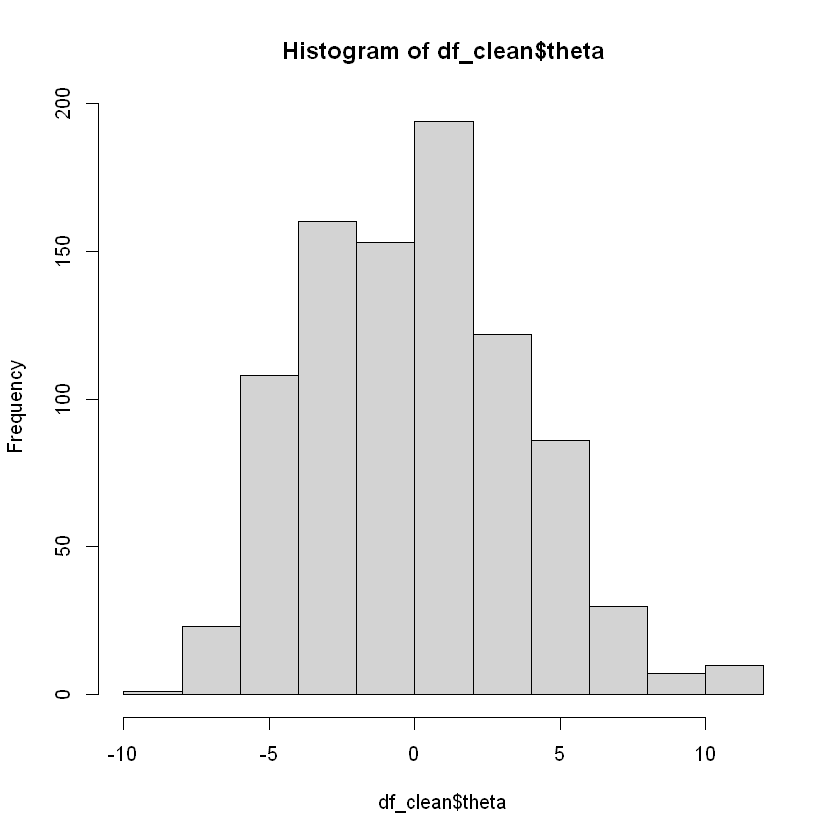

In [145]:
hist(df_clean$theta)

## EFE

In [146]:
KMO(features)

Kaiser-Meyer-Olkin factor adequacy
Call: KMO(r = features)
Overall MSA =  0.84
MSA for each item = 
         n_tech_log           n_hot_log        n_demand_log    tech_skill_score 
               0.80                0.79                0.92                0.87 
tech_activity_score 
               0.85 

In [147]:
cortest.bartlett(features)

R was not square, finding R from data



$chisq
[1] 3122.732

$p.value
[1] 0

$df
[1] 10

Parallel analysis suggests that the number of factors =  2  and the number of components =  NA 


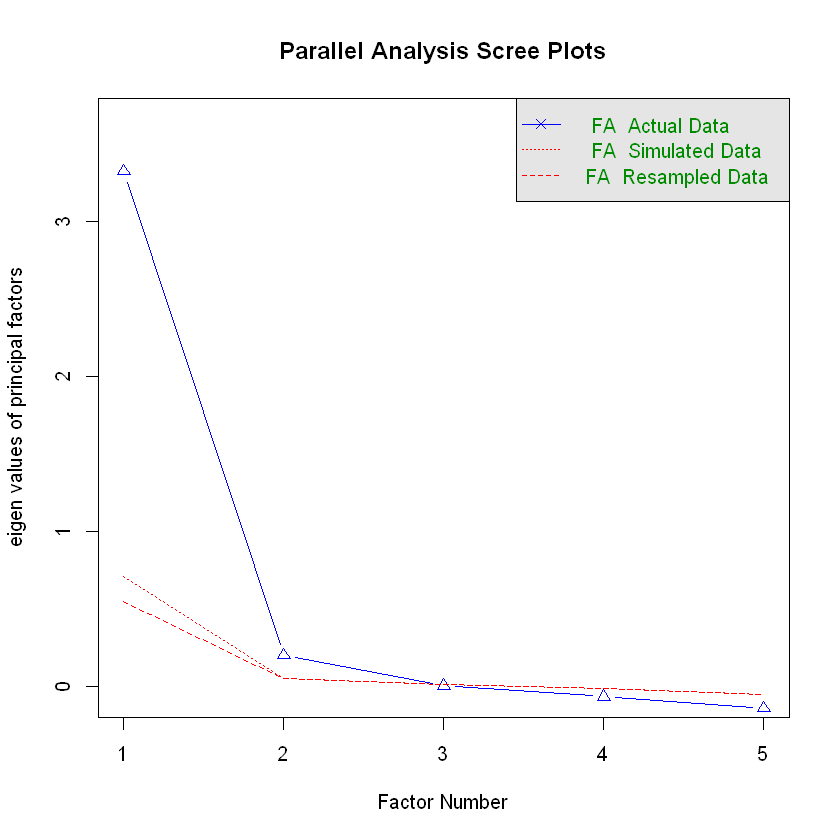

In [148]:
fa.parallel(features, fa = "fa")


Very Simple Structure
Call: vss(x = x, n = n, rotate = rotate, diagonal = diagonal, fm = fm, 
    n.obs = n.obs, plot = plot, title = title, use = use, cor = cor)
VSS complexity 1 achieves a maximimum of 0.95  with  1  factors
VSS complexity 2 achieves a maximimum of 0.97  with  3  factors

The Velicer MAP achieves a minimum of 0.12  with  1  factors 
BIC achieves a minimum of  -5.62  with  2  factors
Sample Size adjusted BIC achieves a minimum of  -2.44  with  2  factors

Statistics by number of factors 
  vss1 vss2  map dof   chisq    prob sqresid  fit RMSEA   BIC SABIC complex
1 0.95 0.00 0.12   5 2.3e+02 2.4e-48    0.68 0.95 0.226 199.1 214.9     1.0
2 0.60 0.97 0.20   1 1.2e+00 2.8e-01    0.37 0.97 0.014  -5.6  -2.4     1.5
3 0.60 0.97 0.44  -2 1.3e-11      NA    0.34 0.98    NA    NA    NA     1.6
4 0.60 0.97 1.00  -4 0.0e+00      NA    0.32 0.98    NA    NA    NA     1.6
5 0.60 0.97   NA  -5 0.0e+00      NA    0.32 0.98    NA    NA    NA     1.6
   eChisq    SRMR  eCRMS eBIC
1 

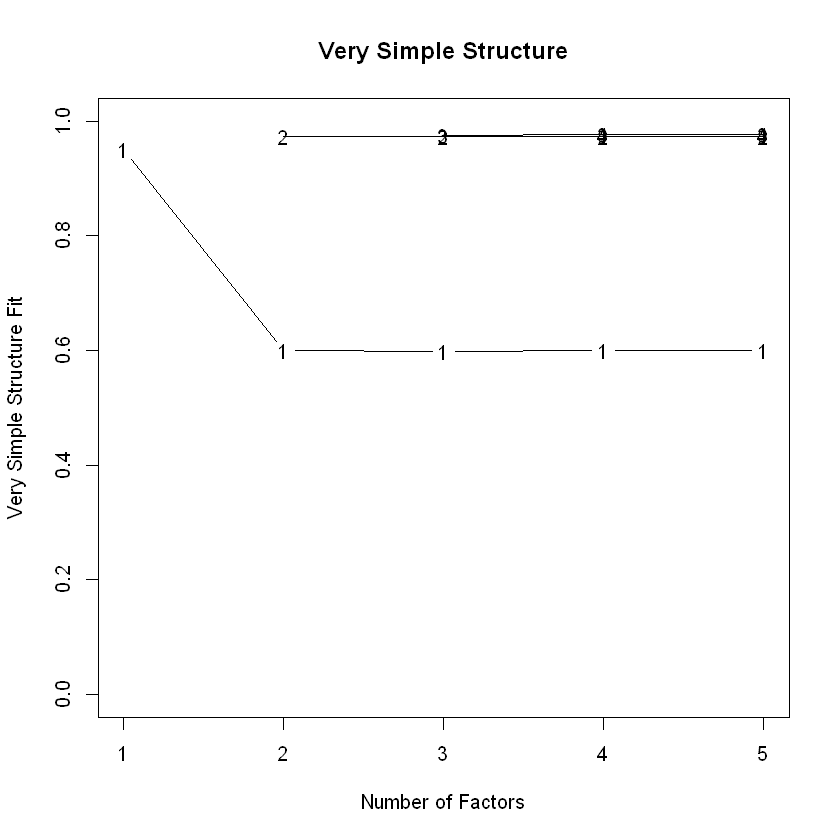

In [149]:
VSS(features)

In [152]:
efa_ml <- fa(features, nfactors = 2, fm = "ml", rotate = "oblimin")

In [153]:
efa_ml$communality

n_tech_log           n_hot_log        n_demand_log    tech_skill_score 
          0.8367097           0.8866281           0.5813561           0.6204215 
tech_activity_score 
          0.8919836

In [154]:
efa_ml$scores

ML1,ML2
0.94069652,1.227824017
0.53865161,0.913462806
1.89467130,0.811562556
1.33250857,0.446383579
2.21190545,0.615216927
1.69907995,0.765480474
1.21128046,0.595076973
1.06866922,0.409435270
0.95897903,0.384662640
0.59818850,0.767919386


In [155]:
cor(efa_ml$scores, df_clean$theta)

ML1,0.9628948
ML2,0.8734577


In [156]:
efa_ml$STATISTIC
efa_ml$dof
efa_ml$PVAL

[1] 0.9537757

[1] 1

[1] 0.3287601

Warning message in fac(r = r, nfactors = nfactors, n.obs = n.obs, rotate = rotate, :
"An ultra-Heywood case was detected.  Examine the results carefully"
Warning message in cov2cor(t(w) %*% r %*% w):
"diag(V) had non-positive or NA entries; the non-finite result may be dubious"


Omega 
Call: omegah(m = m, nfactors = nfactors, fm = fm, key = key, flip = flip, 
    digits = digits, title = title, sl = sl, labels = labels, 
    plot = plot, n.obs = n.obs, rotate = rotate, Phi = Phi, option = option, 
    covar = covar)
Alpha:                 0.91 
G.6:                   0.9 
Omega Hierarchical:    0.77 
Omega H asymptotic:    0.83 
Omega Total            0.93 

Schmid Leiman Factor loadings greater than  0.2 
                       g  F1* F2* F3*   h2   h2   u2   p2  com
n_tech_log          0.73 0.53         0.82 0.82 0.18 0.65 1.83
n_hot_log           0.68 0.66         0.92 0.92 0.08 0.50 2.02
n_demand_log        0.62 0.46         0.60 0.60 0.40 0.64 1.98
tech_skill_score    0.87              0.73 0.73 0.27 1.03 1.04
tech_activity_score 0.84              0.74 0.74 0.26 0.96 1.07

With Sums of squares  of:
   g  F1*  F2*  F3*   h2 
2.85 0.93 0.00 0.07 2.96 

general/max  0.96   max/min =   Inf
mean percent general =  0.76    with sd =  0.23 and cv of  0.3 
Explai

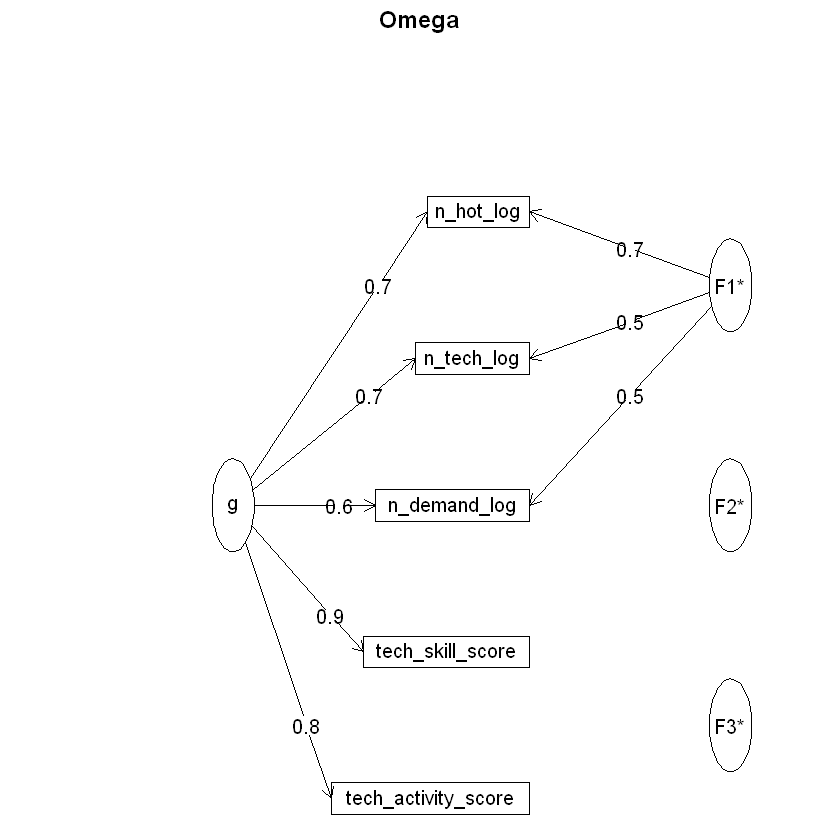

In [157]:
omega(features)

## CFA

### F1 simples

In [188]:
modelo_cfa <- '
TI =~ n_tech_log + n_hot_log + n_demand_log + 
      tech_skill_score + tech_activity_score
'

fit <- cfa(modelo_cfa, data = df_clean, std.lv = TRUE)

In [165]:
summary(fit, fit.measures = TRUE, standardized = TRUE)

lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TI,=~,n_tech_log,0,0.84160888,0.023470092,35.85878,0,0.84160888,0.9280260
TI,=~,n_hot_log,0,0.73418281,0.021350025,34.38791,0,0.73418281,0.9052308
TI,=~,n_demand_log,0,0.69615858,0.026242042,26.52837,0,0.69615858,0.7647721
TI,=~,tech_skill_score,0,0.33320514,0.013236224,25.17373,0,0.33320514,0.7369502
TI,=~,tech_activity_score,0,0.43757977,0.018842157,23.22344,0,0.43757977,0.6946484
n_tech_log,~~,n_tech_log,0,0.11412710,0.010283743,11.09782,0,0.11412710,0.1387677
n_hot_log,~~,n_hot_log,0,0.11876945,0.008827360,13.45470,0,0.11876945,0.1805573
n_demand_log,~~,n_demand_log,0,0.34397730,0.018120353,18.98292,0,0.34397730,0.4151237
tech_skill_score,~~,tech_skill_score,0,0.09340549,0.004831903,19.33100,0,0.09340549,0.4569044


In [166]:
inspect(fit, "std")$lambda

,TI
n_tech_log,0.9280260
n_hot_log,0.9052308
n_demand_log,0.7647721
tech_skill_score,0.7369502
tech_activity_score,0.6946484


In [168]:
reliability(fit)

Warning message in reliability(fit):
"
The reliability() function was deprecated in 2022 and will cease to be included in future versions of semTools. See help('semTools-deprecated) for details.

It is replaced by the compRelSEM() function, which can estimate alpha and model-based reliability in an even wider variety of models and data types, with greater control in specifying the desired type of reliability coefficient (i.e., more explicitly choosing assumptions). 

The average variance extracted should never have been included because it is not a reliability coefficient. It is now available from the AVE() function."


,TI
alpha,0.8928956
omega,0.9135951
omega2,0.9135951
omega3,0.9088832
avevar,0.6991100


In [169]:
loadings <- inspect(fit, "std")$lambda[,1]

CR <- (sum(loadings))^2 / ((sum(loadings))^2 + sum(1 - loadings^2))
CR

[1] 0.9047839

In [170]:
AVE <- sum(loadings^2) / length(loadings)
AVE

[1] 0.6582367

### F2 MLR

In [171]:
modelo_cfa_2f <- '
Infra =~ n_tech_log + n_hot_log + n_demand_log
Use   =~ tech_skill_score + tech_activity_score
'

In [207]:
ajuste_cfa <- cfa(
  model = modelo_cfa_2f,
  data = df_clean,
  estimator = "MLR",
  std.lv = TRUE
)

fitMeasures(
  ajuste_cfa,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower","rmsea.ci.upper","srmr")
)

chisq             df         pvalue            cfi            tli 
        35.921          4.000          0.000          0.990          0.974 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.094          0.068          0.124          0.019

In [200]:
inspect(ajuste_cfa, "std")$lambda

,Infra,Use
n_tech_log,0.9322131,0.0000000
n_hot_log,0.9134458,0.0000000
n_demand_log,0.7617789,0.0000000
tech_skill_score,0.0000000,0.8657411
tech_activity_score,0.0000000,0.8085524


In [179]:
inspect(ajuste_cfa, "std")$psi

,Infra,Use
Infra,1.0000000,0.8225226
Use,0.8225226,1.0000000


In [180]:
reliability(ajuste_cfa)

Warning message in reliability(ajuste_cfa):
"
The reliability() function was deprecated in 2022 and will cease to be included in future versions of semTools. See help('semTools-deprecated) for details.

It is replaced by the compRelSEM() function, which can estimate alpha and model-based reliability in an even wider variety of models and data types, with greater control in specifying the desired type of reliability coefficient (i.e., more explicitly choosing assumptions). 

The average variance extracted should never have been included because it is not a reliability coefficient. It is now available from the AVE() function."


,Infra,Use
alpha,0.8979885,0.7974961
omega,0.9020330,0.8113954
omega2,0.9020330,0.8113954
omega3,0.9033780,0.8113954
avevar,0.7555369,0.6863136


In [204]:
CR <- compRelSEM(ajuste_cfa)
CR

Infra   Use 
0.903 0.811

In [205]:
sqrt_AVE <- sqrt(CR)
sqrt_AVE

Infra   Use 
0.950 0.901

In [212]:
reliability(ajuste_cfa)["avevar",]

Warning message in reliability(ajuste_cfa):
"
The reliability() function was deprecated in 2022 and will cease to be included in future versions of semTools. See help('semTools-deprecated) for details.

It is replaced by the compRelSEM() function, which can estimate alpha and model-based reliability in an even wider variety of models and data types, with greater control in specifying the desired type of reliability coefficient (i.e., more explicitly choosing assumptions). 

The average variance extracted should never have been included because it is not a reliability coefficient. It is now available from the AVE() function."


Infra       Use 
0.7555369 0.6863136

### F1 MLR

In [191]:
fit_1 <- cfa(
  modelo_cfa,
  data = df_clean,
  estimator = "MLR",
  std.lv = TRUE
)

fitMeasures(
  fit_1,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower","rmsea.ci.upper","srmr")
)

chisq             df         pvalue            cfi            tli 
       201.134          5.000          0.000          0.937          0.874 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.209          0.185          0.235          0.053

In [198]:
inspect(fit_1, "std")$lambda

,TI
n_tech_log,0.9280260
n_hot_log,0.9052308
n_demand_log,0.7647721
tech_skill_score,0.7369502
tech_activity_score,0.6946484


In [193]:
reliability(fit_1)

Warning message in reliability(fit_1):
"
The reliability() function was deprecated in 2022 and will cease to be included in future versions of semTools. See help('semTools-deprecated) for details.

It is replaced by the compRelSEM() function, which can estimate alpha and model-based reliability in an even wider variety of models and data types, with greater control in specifying the desired type of reliability coefficient (i.e., more explicitly choosing assumptions). 

The average variance extracted should never have been included because it is not a reliability coefficient. It is now available from the AVE() function."


,TI
alpha,0.8928956
omega,0.9135951
omega2,0.9135951
omega3,0.9088832
avevar,0.6991100


In [195]:
CR <- compRelSEM(fit_1)
CR

TI 
0.909

In [196]:
sqrt_AVE <- sqrt(CR)
sqrt_AVE

TI 
0.953

In [203]:
sqrt_AVE <- sqrt(AVE)
sqrt_AVE

[1] 0.8113179

In [197]:
anova(fit_1, ajuste_cfa)

,Df,AIC,BIC,Chisq,Chisq diff,RMSEA,Df diff,Pr(>Chisq)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
ajuste_cfa,4,6645.357,6698.110,35.92076,NA,NA,NA,NA
fit_1,5,6808.571,6856.528,201.13404,183.9711,0.4287165,1,6.582833e-42
